In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from datetime import datetime, timedelta 
import matplotlib.ticker as mticker 

# === LOAD DATA ===
df = pd.read_excel("jobstreet_data_jobs_final.xlsx")


In [2]:
df.head()

,job_title,company_name,location,job_type,salary,specialization_job,posted_date
0,Data Analyst,PT. TRANSNOVASI BANGUN PERSADA,"Jakarta Selatan, Jakarta Raya",Full time,Rp 6.500.000 – Rp 7.500.000 per month,Analis Bisnis/Sistem (Teknologi Informasi & Ko...,Posted 25 hari yang lalu
1,Sales Data Analyst,PT. Satya Langgeng Sentosa,"Jakarta Barat, Jakarta Raya",Full time,NaN,Analisis & Pelaporan (Penjualan),Tambahkan gaji yang diharapkan ke profil untuk...
2,Data Analyst,PT. MAX AUTO INDONESIA,"Manado, Sulawesi Utara",Kontrak/Temporer,NaN,Pengembangan & Administrasi Database (Teknolog...,Tambahkan gaji yang diharapkan ke profil untuk...
3,Data Analyst Intern,PT Emos Global Digital,"Jakarta Timur, Jakarta Raya",Kontrak/Temporer,NaN,"Matematika, Statistik & Teknik Informasi (Sain...",Tambahkan gaji yang diharapkan ke profil untuk...
4,Data Analyst,A&W Restaurants Indonesia,"Jakarta Utara, Jakarta Raya",Full time,NaN,"Matematika, Statistik & Teknik Informasi (Sain...",Tambahkan gaji yang diharapkan ke profil untuk...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 878 entries, 0 to 877
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   job_title           878 non-null    object
 1   company_name        824 non-null    object
 2   location            768 non-null    object
 3   job_type            768 non-null    object
 4   salary              437 non-null    object
 5   specialization_job  878 non-null    object
 6   posted_date         878 non-null    object
dtypes: object(7)
memory usage: 48.1+ KB


In [4]:
df.isna().sum()

job_title               0
company_name           54
location              110
job_type              110
salary                441
specialization_job      0
posted_date             0
dtype: int64

In [5]:
# === PREPROCESSING ===
# Ganti missing value teks dengan 'unknown'
df['company_name'] = df['company_name'].fillna('unknown')
df['location'] = df['location'].fillna('unknown')
df['job_type'] = df['job_type'].str.lower().str.strip().fillna('unknown')


In [6]:
# --- PENANGANAN KOLOM 'posted_date' ---
# Fungsi kustom untuk mengurai teks tanggal posting
def parse_posted_date(date_text):
    if pd.isna(date_text):
        return np.nan
    date_text = str(date_text).lower() # Konversi ke huruf kecil untuk konsistensi

    # Mengatur tanggal referensi menjadi 31 Mei 2025 sesuai pengambilan data
    today = datetime(2025, 5, 31).date() 

    # Pola untuk "X hari yang lalu"
    match_days_ago = re.search(r'posted (\d+) hari yang lalu', date_text)
    if match_days_ago:
        days_ago = int(match_days_ago.group(1))
        return today - timedelta(days=days_ago)

    # Pola untuk "X jam yang lalu" (jika ada, meskipun di contoh tidak ada)
    match_hours_ago = re.search(r'posted (\d+) jam yang lalu', date_text)
    if match_hours_ago:
        hours_ago = int(match_hours_ago.group(1))
        return today - timedelta(hours=hours_ago)

    # Pola untuk "X menit yang lalu" (jika ada)
    match_minutes_ago = re.search(r'posted (\d+) menit yang lalu', date_text)
    if match_minutes_ago:
        minutes_ago = int(match_minutes_ago.group(1))
        return today - timedelta(minutes=minutes_ago)

    # Pola untuk "X bulan yang lalu" (jika ada)
    match_months_ago = re.search(r'posted (\d+) bulan yang lalu', date_text)
    if match_months_ago:
        months_ago = int(match_months_ago.group(1))
        # Perkiraan kasar: 1 bulan = 30 hari
        return today - timedelta(days=months_ago * 30)

    # Pola untuk "X tahun yang lalu" (jika ada)
    match_years_ago = re.search(r'posted (\d+) tahun yang lalu', date_text)
    if match_years_ago:
        years_ago = int(match_years_ago.group(1))
        # Perkiraan kasar: 1 tahun = 365 hari
        return today - timedelta(days=years_ago * 365)

    # Jika tidak ada pola yang cocok, atau teks instruksional, kembalikan NaT
    return np.nan

# Terapkan fungsi kustom ke kolom 'posted_date'
df['posted_date'] = df['posted_date'].apply(parse_posted_date)
# Konversi eksplisit posted_date_clean ke tipe datetime
df['posted_date'] = pd.to_datetime(df['posted_date'])


In [7]:
df.isna().sum()

job_title               0
company_name            0
location                0
job_type                0
salary                441
specialization_job      0
posted_date           441
dtype: int64

In [8]:
# Normalisasi job_title: huruf kecil dan hapus karakter non-alfabet
df['job_title'] = df['job_title'].str.lower()
df['job_title'] = df['job_title'].apply(lambda x: re.sub(r'[^a-z\s]', '', x).strip())

In [9]:
# Parsing salary
def parse_salary(s):
    if pd.isna(s):
        return np.nan, np.nan
    s = s.replace("Rp", "").replace("per month", "").replace("\xa0", "").replace(".", "")
    parts = re.findall(r'\d+', s)
    if len(parts) == 2:
        return int(parts[0]), int(parts[1])
    elif len(parts) == 1:
        return int(parts[0]), int(parts[0])
    else:
        return np.nan, np.nan

df[['min_salary', 'max_salary']] = df['salary'].apply(lambda x: pd.Series(parse_salary(x)))

In [10]:
df.head()

,job_title,company_name,location,job_type,salary,specialization_job,posted_date,min_salary,max_salary
0,data analyst,PT. TRANSNOVASI BANGUN PERSADA,"Jakarta Selatan, Jakarta Raya",full time,Rp 6.500.000 – Rp 7.500.000 per month,Analis Bisnis/Sistem (Teknologi Informasi & Ko...,2025-05-06,6500000.0,7500000.0
1,sales data analyst,PT. Satya Langgeng Sentosa,"Jakarta Barat, Jakarta Raya",full time,NaN,Analisis & Pelaporan (Penjualan),NaT,NaN,NaN
2,data analyst,PT. MAX AUTO INDONESIA,"Manado, Sulawesi Utara",kontrak/temporer,NaN,Pengembangan & Administrasi Database (Teknolog...,NaT,NaN,NaN
3,data analyst intern,PT Emos Global Digital,"Jakarta Timur, Jakarta Raya",kontrak/temporer,NaN,"Matematika, Statistik & Teknik Informasi (Sain...",NaT,NaN,NaN
4,data analyst,A&W Restaurants Indonesia,"Jakarta Utara, Jakarta Raya",full time,NaN,"Matematika, Statistik & Teknik Informasi (Sain...",NaT,NaN,NaN


In [11]:
# Ekstrak lokasi
def extract_location(loc):
    if pd.isna(loc) or loc == 'unknown':
        return pd.Series(['unknown', 'unknown'])
    parts = loc.split(",")
    city = parts[0].strip()
    province = parts[1].strip() if len(parts) > 1 else 'unknown'
    return pd.Series([city, province])

df[['city', 'province']] = df['location'].apply(extract_location)
df.head()

,job_title,company_name,location,job_type,salary,specialization_job,posted_date,min_salary,max_salary,city,province
0,data analyst,PT. TRANSNOVASI BANGUN PERSADA,"Jakarta Selatan, Jakarta Raya",full time,Rp 6.500.000 – Rp 7.500.000 per month,Analis Bisnis/Sistem (Teknologi Informasi & Ko...,2025-05-06,6500000.0,7500000.0,Jakarta Selatan,Jakarta Raya
1,sales data analyst,PT. Satya Langgeng Sentosa,"Jakarta Barat, Jakarta Raya",full time,NaN,Analisis & Pelaporan (Penjualan),NaT,NaN,NaN,Jakarta Barat,Jakarta Raya
2,data analyst,PT. MAX AUTO INDONESIA,"Manado, Sulawesi Utara",kontrak/temporer,NaN,Pengembangan & Administrasi Database (Teknolog...,NaT,NaN,NaN,Manado,Sulawesi Utara
3,data analyst intern,PT Emos Global Digital,"Jakarta Timur, Jakarta Raya",kontrak/temporer,NaN,"Matematika, Statistik & Teknik Informasi (Sain...",NaT,NaN,NaN,Jakarta Timur,Jakarta Raya
4,data analyst,A&W Restaurants Indonesia,"Jakarta Utara, Jakarta Raya",full time,NaN,"Matematika, Statistik & Teknik Informasi (Sain...",NaT,NaN,NaN,Jakarta Utara,Jakarta Raya


In [12]:
df.isna().sum()

job_title               0
company_name            0
location                0
job_type                0
salary                441
specialization_job      0
posted_date           441
min_salary            441
max_salary            441
city                    0
province                0
dtype: int64

In [13]:
df.head()

,job_title,company_name,location,job_type,salary,specialization_job,posted_date,min_salary,max_salary,city,province
0,data analyst,PT. TRANSNOVASI BANGUN PERSADA,"Jakarta Selatan, Jakarta Raya",full time,Rp 6.500.000 – Rp 7.500.000 per month,Analis Bisnis/Sistem (Teknologi Informasi & Ko...,2025-05-06,6500000.0,7500000.0,Jakarta Selatan,Jakarta Raya
1,sales data analyst,PT. Satya Langgeng Sentosa,"Jakarta Barat, Jakarta Raya",full time,NaN,Analisis & Pelaporan (Penjualan),NaT,NaN,NaN,Jakarta Barat,Jakarta Raya
2,data analyst,PT. MAX AUTO INDONESIA,"Manado, Sulawesi Utara",kontrak/temporer,NaN,Pengembangan & Administrasi Database (Teknolog...,NaT,NaN,NaN,Manado,Sulawesi Utara
3,data analyst intern,PT Emos Global Digital,"Jakarta Timur, Jakarta Raya",kontrak/temporer,NaN,"Matematika, Statistik & Teknik Informasi (Sain...",NaT,NaN,NaN,Jakarta Timur,Jakarta Raya
4,data analyst,A&W Restaurants Indonesia,"Jakarta Utara, Jakarta Raya",full time,NaN,"Matematika, Statistik & Teknik Informasi (Sain...",NaT,NaN,NaN,Jakarta Utara,Jakarta Raya


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 878 entries, 0 to 877
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   job_title           878 non-null    object        
 1   company_name        878 non-null    object        
 2   location            878 non-null    object        
 3   job_type            878 non-null    object        
 4   salary              437 non-null    object        
 5   specialization_job  878 non-null    object        
 6   posted_date         437 non-null    datetime64[ns]
 7   min_salary          437 non-null    float64       
 8   max_salary          437 non-null    float64       
 9   city                878 non-null    object        
 10  province            878 non-null    object        
dtypes: datetime64[ns](1), float64(2), object(8)
memory usage: 75.6+ KB


C:\Users\USER\AppData\Local\Temp\ipykernel_26004\3749051714.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_titles.values, y=top_titles.index, palette='viridis')


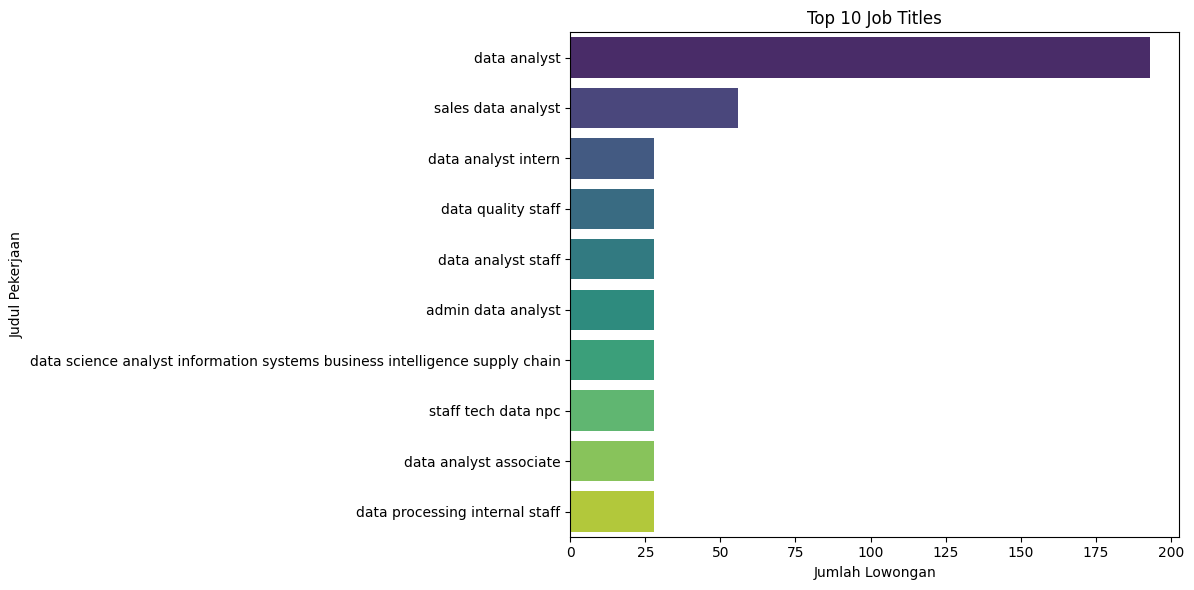

In [15]:
#5. Visualisasi Top 10 Job Titles
top_titles = df['job_title'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_titles.values, y=top_titles.index, palette='viridis')
plt.title('Top 10 Job Titles')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Judul Pekerjaan')
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_26004\487815165.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_type_dist.values, y=job_type_dist.index, palette="rocket")


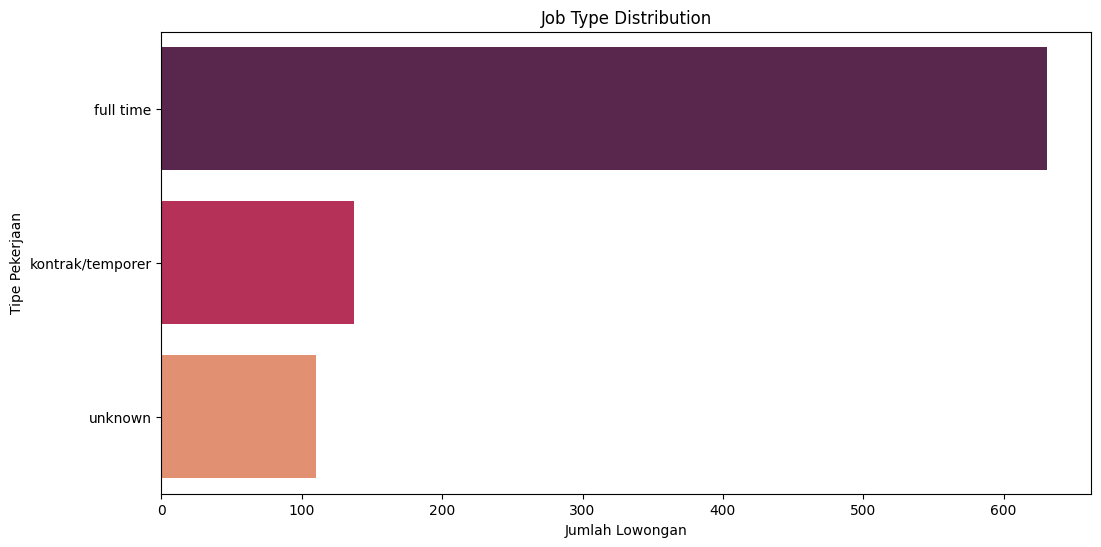

In [16]:
job_type_dist = df['job_type'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=job_type_dist.values, y=job_type_dist.index, palette="rocket")
plt.title("Job Type Distribution")
plt.xlabel("Jumlah Lowongan")
plt.ylabel("Tipe Pekerjaan")
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_26004\1149311532.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_specializations.values, y=top_specializations.index, palette="magma")


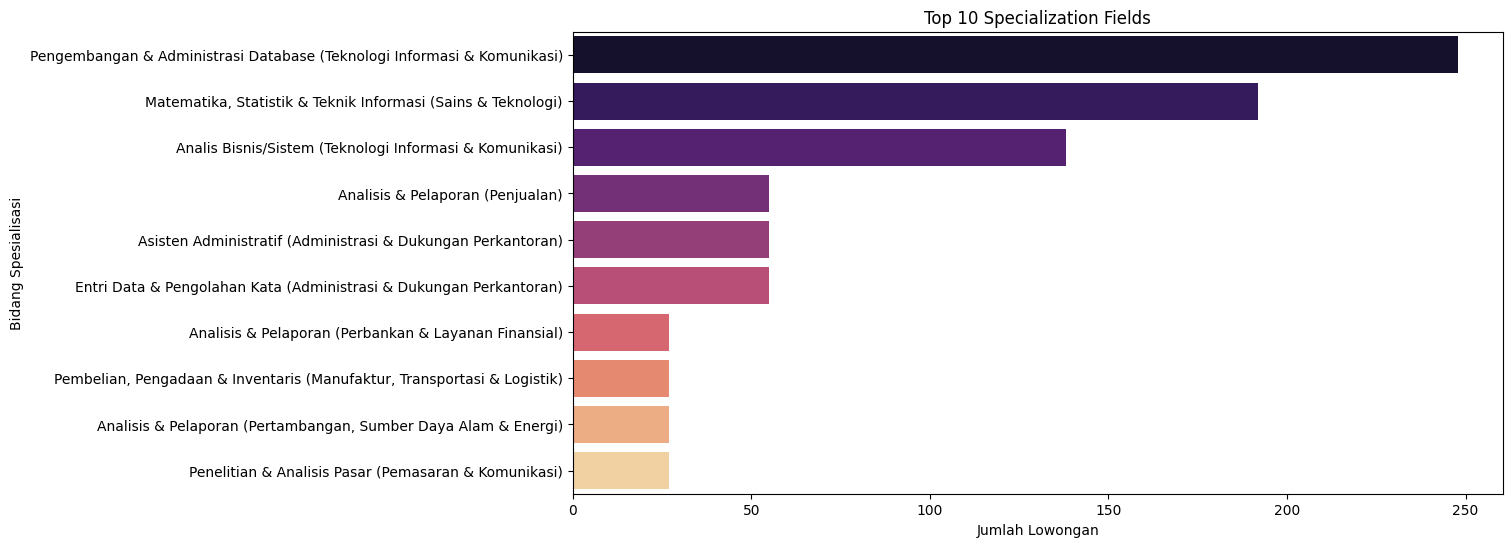

In [17]:
top_specializations = df['specialization_job'].value_counts().nlargest(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_specializations.values, y=top_specializations.index, palette="magma")
plt.title("Top 10 Specialization Fields")
plt.xlabel("Jumlah Lowongan")
plt.ylabel("Bidang Spesialisasi")
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_26004\3076958184.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette="coolwarm")


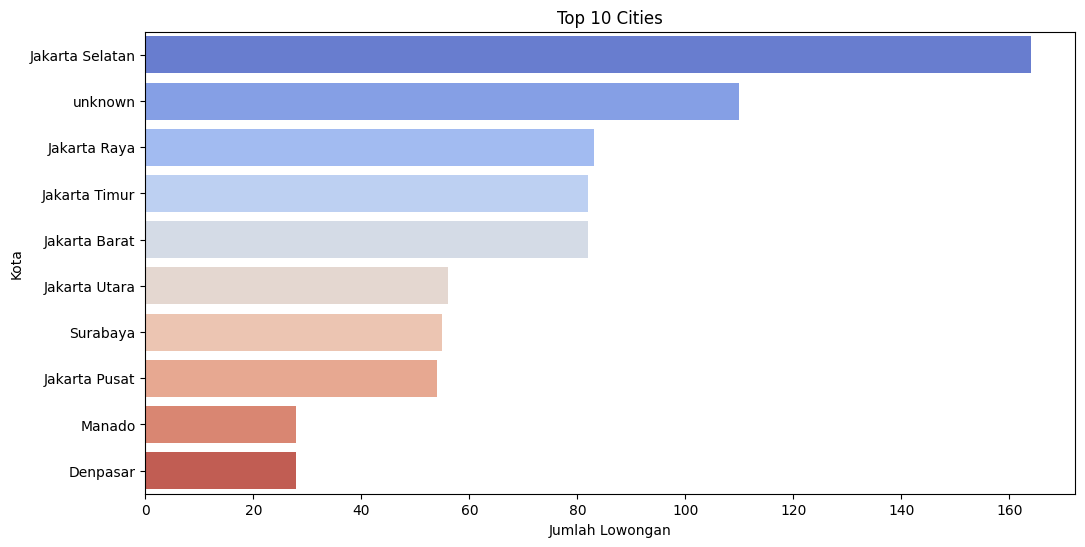

In [18]:
top_cities = df['city'].value_counts().nlargest(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_cities.values, y=top_cities.index, palette="coolwarm")
plt.title("Top 10 Cities")
plt.xlabel("Jumlah Lowongan")
plt.ylabel("Kota")
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_26004\4148397969.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_provinces.values, y=top_provinces.index, palette="cubehelix")


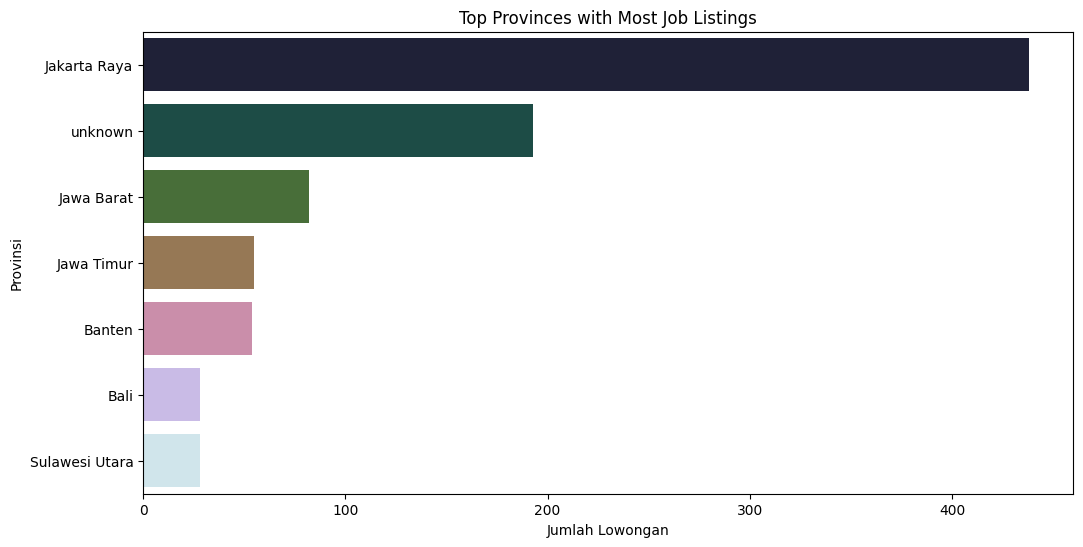

In [19]:
top_provinces = df['province'].value_counts().nlargest(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_provinces.values, y=top_provinces.index, palette="cubehelix")
plt.title("Top Provinces with Most Job Listings")
plt.xlabel("Jumlah Lowongan")
plt.ylabel("Provinsi")
plt.show()


In [20]:
print(df[['min_salary', 'max_salary']].sort_values(by='max_salary', ascending=False).head(10))

     min_salary  max_salary
819  20000000.0  30000000.0
50   20000000.0  30000000.0
787  20000000.0  30000000.0
691  20000000.0  30000000.0
723  20000000.0  30000000.0
755  20000000.0  30000000.0
659  20000000.0  30000000.0
627  20000000.0  30000000.0
595  20000000.0  30000000.0
114  20000000.0  30000000.0


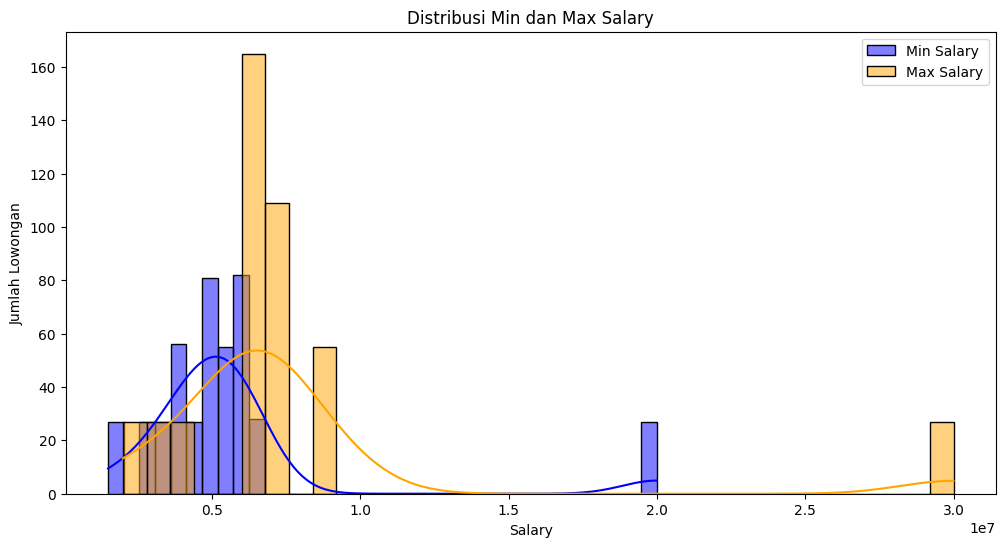

In [21]:
plt.figure(figsize=(12, 6))
sns.histplot(df['min_salary'], bins=35, kde=True, color='blue', label='Min Salary')
sns.histplot(df['max_salary'], bins=35, kde=True, color='orange', label='Max Salary')
plt.legend()
plt.title('Distribusi Min dan Max Salary')
plt.xlabel('Salary')
plt.ylabel('Jumlah Lowongan')
plt.show()

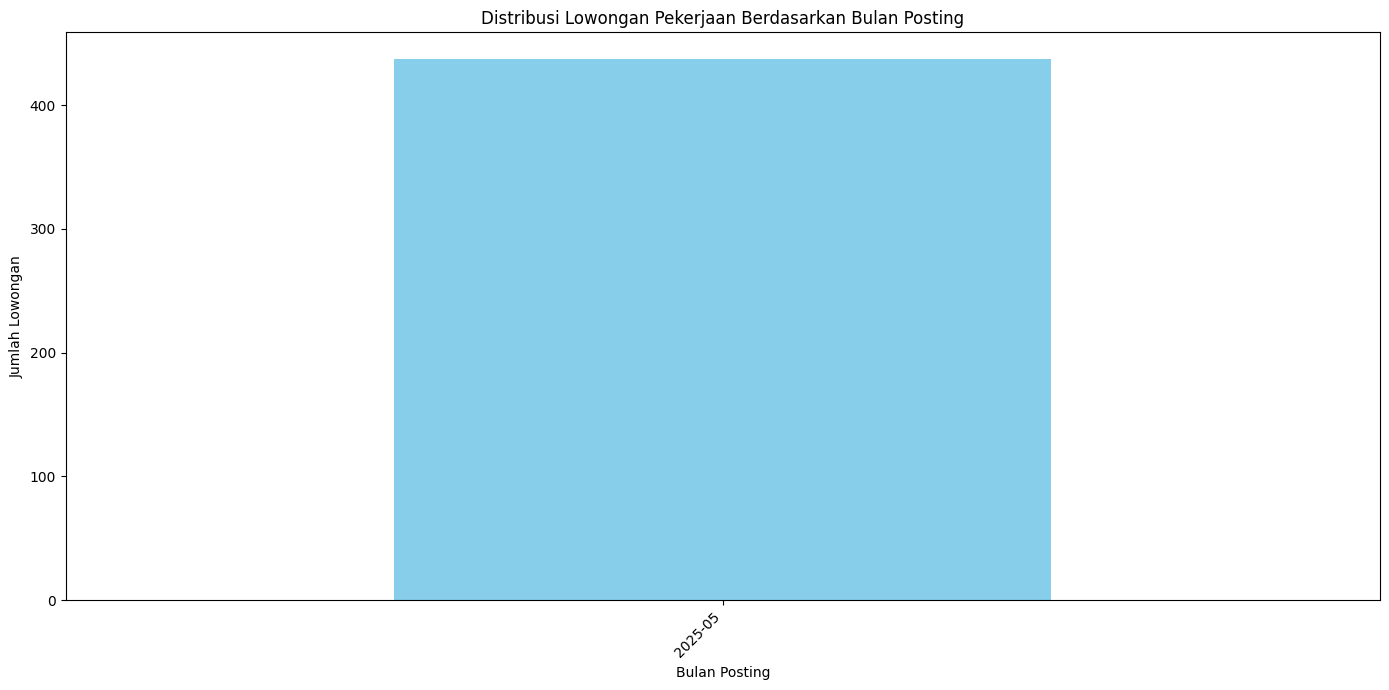

In [22]:
# Hapus baris dengan NaT pada posted_date_clean agar tidak mengganggu analisis tren
df_clean_dates = df.dropna(subset=['posted_date']).copy()

# Ekstrak Tahun dan Bulan
df_clean_dates['posted_year_month'] = df_clean_dates['posted_date'].dt.to_period('M')

# Hitung frekuensi posting per bulan
monthly_postings = df_clean_dates['posted_year_month'].value_counts().sort_index()

plt.figure(figsize=(14, 7))
monthly_postings.plot(kind='bar', color='skyblue')
plt.title('Distribusi Lowongan Pekerjaan Berdasarkan Bulan Posting')
plt.xlabel('Bulan Posting')
plt.ylabel('Jumlah Lowongan')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [23]:
# Filter data for salary analysis (drop NaN in avg_salary column)
df['avg_salary'] = (df['min_salary'] + df['max_salary']) / 2
df_salary_analysis = df.dropna(subset=['avg_salary']).copy()

# Custom function to format salary axis to Rupiah format
def rupiah_formatter(x, pos):
    return f"Rp {int(x):,.0f}"

formatter = mticker.FuncFormatter(rupiah_formatter)

# 2.1. Distribusi Gaji Rata-rata Berdasarkan Top 10 Kota (Gambar 4.11)
print("\n--- Analisis Hubungan Gaji dengan Lokasi (Kota) ---")
top_10_cities_for_salary = df_salary_analysis['city'].value_counts().nlargest(10).index
df_top_cities_salary = df_salary_analysis[df_salary_analysis['city'].isin(top_10_cities_for_salary)]

plt.figure(figsize=(14, 8))
sns.boxplot(x='avg_salary', y='city', data=df_top_cities_salary.sort_values('avg_salary', ascending=False), palette='coolwarm')
plt.title('Distribusi Gaji Rata-rata Berdasarkan Top 10 Kota')
plt.xlabel('Gaji Rata-rata')
plt.ylabel('Kota')
plt.gca().xaxis.set_major_formatter(formatter) # Apply formatter
plt.tight_layout()
plt.show()

# 2.2. Distribusi Gaji Rata-rata Berdasarkan Top 10 Bidang Spesialisasi (Gambar 4.12)
print("\n--- Analisis Hubungan Gaji dengan Spesialisasi ---")
top_10_specializations_for_salary = df_salary_analysis['specialization_job'].value_counts().nlargest(10).index
df_top_specializations_salary = df_salary_analysis[df_salary_analysis['specialization_job'].isin(top_10_specializations_for_salary)]

plt.figure(figsize=(14, 8))
sns.boxplot(x='avg_salary', y='specialization_job', data=df_top_specializations_salary.sort_values('avg_salary', ascending=False), palette='magma')
plt.title('Distribusi Gaji Rata-rata Berdasarkan Top 10 Bidang Spesialisasi')
plt.xlabel('Gaji Rata-rata')
plt.ylabel('Bidang Spesialisasi')
plt.gca().xaxis.set_major_formatter(formatter) # Apply formatter
plt.tight_layout()
plt.show()

NameError: name 'mticker' is not defined

C:\Users\USER\AppData\Local\Temp\ipykernel_10252\488352358.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_companies.values, y=top_10_companies.index, palette='viridis')



--- Analisis Perusahaan Perekrut Teratas ---


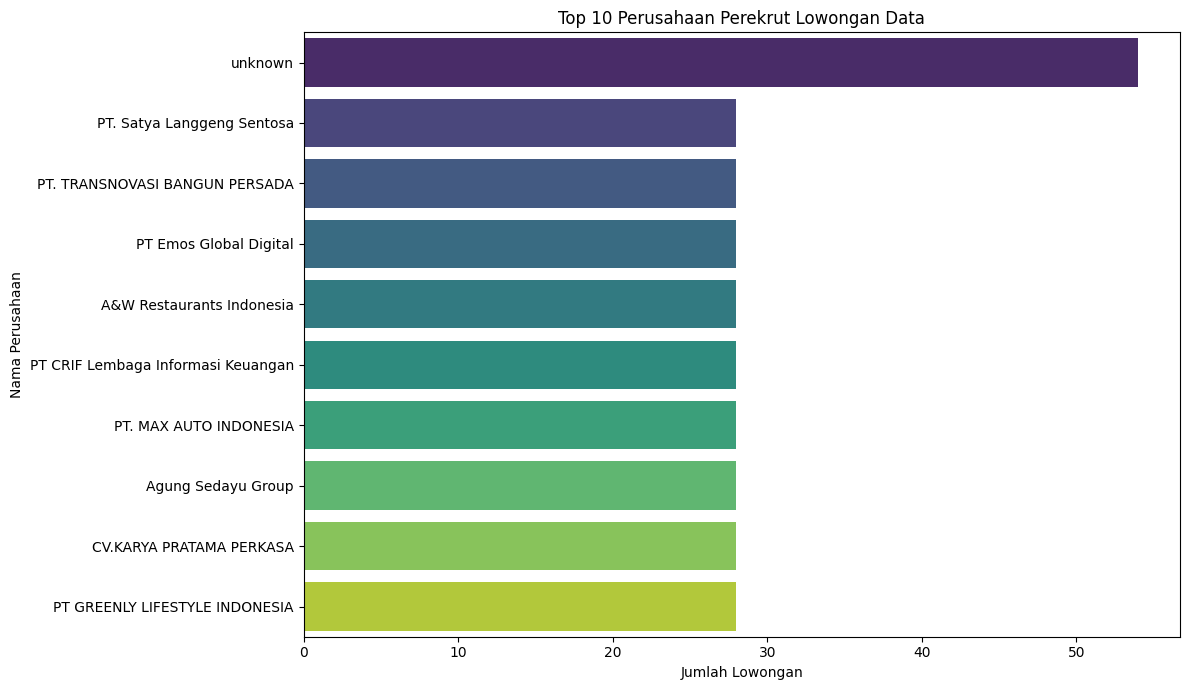

In [ ]:
# 3. Analisis Perusahaan Perekrut Teratas (Gambar 4.13)
print("\n--- Analisis Perusahaan Perekrut Teratas ---")
top_10_companies = df['company_name'].value_counts().nlargest(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_companies.values, y=top_10_companies.index, palette='viridis')
plt.title('Top 10 Perusahaan Perekrut Lowongan Data')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Nama Perusahaan')
plt.tight_layout()
plt.show()